# Roman Urdu Hate Speech Detection
## Notebook 03 : Model Training 

**Team:** Muhammad Hunain Ashraf (463395) | Arfa Abdul Nasir (456634) 

### Models
 
- B1 | LR + TF-IDF | 
- B2 | SVM + TF-IDF | 
- M1 | TextCNN + fastText init |
- M2 | BiGRU + Attention + fastText init |
- M3 | DualEncoder (Word+Char CNN) + fastText + multi-task |
- M4 | CNN-BiGRU Hierarchical Attn + fastText + multi-task |
- M5 | XLM-RoBERTa | 
- M6 | Soft Ensemble (M3+M4) Probability averaging|



## 0. Setup & GPU Check

In [ ]:
!pip install transformers sentencepiece scikit-learn torch --quiet

import os, json, time, ast, warnings, random, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              accuracy_score, confusion_matrix,
                              classification_report)
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'Memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

os.makedirs('./checkpoints', exist_ok=True)
os.makedirs('./results',     exist_ok=True)

Device : cuda
GPU    : Tesla T4
Memory : 15.6 GB


---
## 1. Load Artefacts & Data

In [ ]:
with open('./artefacts/config.json') as f:
    CONFIG = json.load(f)
print('Config:', json.dumps(CONFIG, indent=2))

VOCAB_SIZE       = CONFIG['vocab_size']
CHAR_VOCAB_SIZE  = CONFIG['char_vocab_size']
PAD_IDX          = CONFIG['pad_idx']
UNK_IDX          = CONFIG['unk_idx']
CHAR_PAD_IDX     = CONFIG['char_pad_idx']
MAX_SEQ_LEN      = CONFIG['max_seq_len']
CHAR_MAX_LEN     = CONFIG['char_max_len']
EMBED_DIM        = CONFIG['embed_dim']
NUM_FINE_CLASSES = CONFIG['num_fine_classes']

with open('./artefacts/word2idx.json',  encoding='utf-8') as f: word2idx = json.load(f)
with open('./artefacts/idx2word.json',  encoding='utf-8') as f: idx2word = {int(k): v for k,v in json.load(f).items()}
with open('./artefacts/char2idx.json')  as f: char2idx = json.load(f)
with open('./artefacts/label2idx.json') as f: label2idx = json.load(f)
with open('./artefacts/idx2label.json') as f: idx2label = {int(k): v for k,v in json.load(f).items()}

# numpy arrays 
X_train      = np.load('./artefacts/X_train.npy')
X_train_char = np.load('./artefacts/X_train_char.npy')
y_train      = np.load('./artefacts/y_train.npy')
y_train_fg   = np.load('./artefacts/y_train_fg.npy')

X_val        = np.load('./artefacts/X_val.npy')
X_val_char   = np.load('./artefacts/X_val_char.npy')
y_val        = np.load('./artefacts/y_val.npy')
y_val_fg     = np.load('./artefacts/y_val_fg.npy')

X_test       = np.load('./artefacts/X_test.npy')
X_test_char  = np.load('./artefacts/X_test_char.npy')
y_test       = np.load('./artefacts/y_test.npy')
y_test_fg    = np.load('./artefacts/y_test_fg.npy')

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'Fine-grained labels in train (non-masked): {(y_train_fg != -1).sum():,}')

# fastText embedding matrix
embed_matrix = np.load('./artefacts/embed_matrix.npy')   # (VOCAB_SIZE, EMBED_DIM)
print(f'Embedding matrix: {embed_matrix.shape}')

# Text splits for TF-IDF baselines 
df_train = pd.read_csv('./data/processed/train.csv')
df_val   = pd.read_csv('./data/processed/val.csv')
df_test  = pd.read_csv('./data/processed/test.csv')
train_texts = df_train['text_clean'].tolist()
val_texts   = df_val['text_clean'].tolist()
test_texts  = df_test['text_clean'].tolist()
print('Text splits loaded.')

Config: {
  "vocab_size": 34043,
  "char_vocab_size": 42,
  "pad_idx": 0,
  "unk_idx": 1,
  "char_pad_idx": 0,
  "max_seq_len": 64,
  "char_max_len": 200,
  "embed_dim": 100,
  "min_freq": 3,
  "num_classes": 2,
  "num_fine_classes": 5,
  "random_seed": 42,
  "train_size": 89985,
  "val_size": 14833,
  "test_size": 14833,
  "fasttext_dim": 100
}
Train: (89985, 64) | Val: (14833, 64) | Test: (14833, 64)
Fine-grained labels in train (non-masked): 8,397
Embedding matrix: (34043, 100)
Text splits loaded.



## 2. Shared Utilities: Evaluation, Early Stopping, Training Engine

In [ ]:
ALL_RESULTS = {}

def evaluate_predictions(y_true, y_pred, model_name, verbose=True):
    metrics = {
        'accuracy':    round(accuracy_score(y_true, y_pred), 4),
        'f1_weighted': round(f1_score(y_true, y_pred, average='weighted'), 4),
        'f1_hate':     round(f1_score(y_true, y_pred, pos_label=1, average='binary'), 4),
        'f1_not_hate': round(f1_score(y_true, y_pred, pos_label=0, average='binary'), 4),
        'precision':   round(precision_score(y_true, y_pred, average='weighted'), 4),
        'recall':      round(recall_score(y_true, y_pred, average='weighted'), 4),
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist(),
    }
    ALL_RESULTS[model_name] = metrics
    if verbose:
        print(f'\n=== {model_name} ===')
        for k, v in metrics.items():
            if k != 'confusion_matrix': print(f'  {k:<18}: {v}')
        print(classification_report(y_true, y_pred, target_names=['not_hate', 'hate']))
    return metrics


def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['not_hate','hate'], yticklabels=['not_hate','hate'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {model_name}')
    plt.tight_layout()
    plt.savefig(f'./results/cm_{model_name.replace(" ","_")}.png', bbox_inches='tight')
    plt.show()


def plot_training_curves(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history['train_loss'], label='Train Loss', color=PALETTE[0])
    axes[0].plot(history['val_loss'],   label='Val Loss',   color=PALETTE[1])
    axes[0].set_title(f'{model_name} — Loss'); axes[0].legend()
    axes[1].plot(history['train_f1'], label='Train F1', color=PALETTE[0])
    axes[1].plot(history['val_f1'],   label='Val F1',   color=PALETTE[1])
    axes[1].set_title(f'{model_name} — Weighted F1'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f'./results/curves_{model_name.replace(" ","_")}.png', bbox_inches='tight')
    plt.show()


class EarlyStopping:
    def __init__(self, patience=5, mode='max', min_delta=1e-4):
        self.patience   = patience
        self.mode       = mode
        self.min_delta  = min_delta
        self.best       = -np.inf if mode == 'max' else np.inf
        self.counter    = 0
        self.stop       = False

    def __call__(self, value):
        improved = (value > self.best + self.min_delta) if self.mode == 'max' \
                   else (value < self.best - self.min_delta)
        if improved:
            self.best    = value
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

print('Utilities ready.')

Utilities ready.



## 3. Dataset Classes

In [ ]:
class HateSpeechDataset(Dataset):
    """Word-level only dataset (for TextCNN, BiGRU)."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


class DualDataset(Dataset):
    """Word + Char + binary label + fine-grained label."""
    def __init__(self, X_word, X_char, y, y_fg):
        self.X_word = torch.tensor(X_word, dtype=torch.long)
        self.X_char = torch.tensor(X_char, dtype=torch.long)
        self.y      = torch.tensor(y,      dtype=torch.long)
        self.y_fg   = torch.tensor(y_fg,   dtype=torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i):
        return self.X_word[i], self.X_char[i], self.y[i], self.y_fg[i]


BATCH = 128

# Word-only loaders — use num_workers=0 for Windows compatibility
train_loader = DataLoader(HateSpeechDataset(X_train, y_train), batch_size=BATCH, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(HateSpeechDataset(X_val,   y_val),   batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(HateSpeechDataset(X_test,  y_test),  batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=False)

# Dual (word+char+fg) loaders — for DualEncoder & CNN-BiGRU
dual_train_loader = DataLoader(DualDataset(X_train, X_train_char, y_train, y_train_fg), batch_size=BATCH, shuffle=True,  num_workers=0, pin_memory=False)
dual_val_loader   = DataLoader(DualDataset(X_val,   X_val_char,   y_val,   y_val_fg),   batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=False)
dual_test_loader  = DataLoader(DualDataset(X_test,  X_test_char,  y_test,  y_test_fg),  batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=False)

print('Datasets & DataLoaders ready.')

Datasets & DataLoaders ready.



## 4. fastText Embedding Helper

All DL models call `load_pretrained_embedding()` to initialise their embedding layer.
Padding row stays zero. Tokens not in fastText keep a random init.

In [ ]:
def load_pretrained_embedding(embedding_layer: nn.Embedding, embed_matrix: np.ndarray,
                               freeze: bool = False):
    assert embed_matrix.shape == (embedding_layer.weight.shape[0],
                                   embedding_layer.weight.shape[1]), \
        f'Shape mismatch: embedding {embedding_layer.weight.shape} vs matrix {embed_matrix.shape}'

    with torch.no_grad():
        embedding_layer.weight.copy_(torch.tensor(embed_matrix, dtype=torch.float32))
        embedding_layer.weight[0] = 0.0   # PAD stays zero

    embedding_layer.weight.requires_grad = not freeze
    status = 'frozen' if freeze else 'fine-tunable'
    print(f'  [fastText] Embedding initialised ({status}): {embed_matrix.shape}')


print('Embedding helper ready.')

Embedding helper ready.



## 5. Training Engine (supports word-only & dual-encoder & multi-task)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion_main, criterion_aux,
                    scaler, mode='word', aux_weight=0.3):
    """
    mode: 'word'  batch = (x_word, y)
          'dual'  batch = (x_word, x_char, y, y_fg)  [multi-task]
    aux_weight: weight for auxiliary fine-grained loss (ignored when mode='word')
    """
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []

    for batch in loader:
        optimizer.zero_grad()

        if mode == 'word':
            x_word, labels = [b.to(DEVICE) for b in batch]
            with autocast(enabled=(DEVICE.type == 'cuda')):
                logits = model(x_word)
                loss   = criterion_main(logits, labels)

        else:   # dual / multi-task
            x_word, x_char, labels, labels_fg = [b.to(DEVICE) for b in batch]
            with autocast(enabled=(DEVICE.type == 'cuda')):
                logits_main, logits_aux = model(x_word, x_char)
                loss_main = criterion_main(logits_main, labels)
                # Masked aux loss: only compute on samples where label_fg != -1
                mask = labels_fg != -1
                if mask.sum() > 0:
                    loss_aux = criterion_aux(logits_aux[mask], labels_fg[mask])
                    loss = loss_main + aux_weight * loss_aux
                else:
                    loss = loss_main
                logits = logits_main

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * labels.size(0)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return avg_loss, f1


@torch.no_grad()
def evaluate_model(model, loader, criterion_main, mode='word'):
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0.0, [], [], []

    for batch in loader:
        if mode == 'word':
            x_word, labels = [b.to(DEVICE) for b in batch]
            with autocast(enabled=(DEVICE.type == 'cuda')):
                logits = model(x_word)
                loss   = criterion_main(logits, labels)
        else:
            x_word, x_char, labels, _ = [b.to(DEVICE) for b in batch]
            with autocast(enabled=(DEVICE.type == 'cuda')):
                logits, _ = model(x_word, x_char)
                loss = criterion_main(logits, labels)

        probs = F.softmax(logits, dim=1)
        total_loss += loss.item() * labels.size(0)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return avg_loss, f1, np.array(all_preds), np.array(all_labels), np.array(all_probs)


def train_model(model, train_loader, val_loader, model_name,
                max_epochs=30, lr=1e-3, patience=5, weight_decay=1e-4,
                mode='word', use_cosine_lr=False, aux_weight=0.3):

    model = model.to(DEVICE)
    criterion_main = nn.CrossEntropyLoss()
    criterion_aux  = nn.CrossEntropyLoss()  # for fine-grained head
    optimizer  = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler  = (CosineAnnealingLR(optimizer, T_max=max_epochs, eta_min=lr*0.01)
                  if use_cosine_lr
                  else ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, min_lr=1e-6))
    scaler     = GradScaler(enabled=(DEVICE.type == 'cuda'))
    early_stop = EarlyStopping(patience=patience, mode='max')

    history   = defaultdict(list)
    best_f1   = -np.inf
    best_ckpt = f'./checkpoints/{model_name.replace(" ","_")}.pt'

    print(f'\n{"="*60}')
    print(f'Training: {model_name}')
    print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
    print(f'Mode: {mode} | Aux weight: {aux_weight if mode=="dual" else "N/A"}')
    print(f'{"="*60}')

    t_start = time.time()
    for epoch in range(1, max_epochs + 1):
        t_ep = time.time()
        tr_loss, tr_f1 = train_one_epoch(model, train_loader, optimizer,
                                          criterion_main, criterion_aux, scaler,
                                          mode, aux_weight)
        va_loss, va_f1, _, _, _ = evaluate_model(model, val_loader, criterion_main, mode)

        history['train_loss'].append(tr_loss)
        history['train_f1'].append(tr_f1)
        history['val_loss'].append(va_loss)
        history['val_f1'].append(va_f1)

        if use_cosine_lr: scheduler.step()
        else:             scheduler.step(va_f1)

        if va_f1 > best_f1:
            best_f1 = va_f1
            torch.save(model.state_dict(), best_ckpt)

        early_stop(va_f1)
        marker = ' ← best' if va_f1 == best_f1 else ''
        print(f'Ep {epoch:02d}/{max_epochs} | tr_loss={tr_loss:.4f} tr_f1={tr_f1:.4f} | '
              f'va_loss={va_loss:.4f} va_f1={va_f1:.4f} | {time.time()-t_ep:.1f}s{marker}')

        if early_stop.stop:
            print(f'Early stopping at epoch {epoch}.')
            break

    print(f'Total: {(time.time()-t_start)/60:.1f} min | Best val F1: {best_f1:.4f}')
    return dict(history), best_ckpt, best_f1


print('Training engine ready.')

Training engine ready.



## 6. Baselines: LR + TF-IDF and SVM + TF-IDF

LR training time: 14.5s

=== LR+TFIDF ===
  accuracy          : 0.8944
  f1_weighted       : 0.8954
  f1_hate           : 0.8265
  f1_not_hate       : 0.9241
  precision         : 0.8972
  recall            : 0.8944
              precision    recall  f1-score   support

    not_hate       0.94      0.91      0.92     10470
        hate       0.80      0.85      0.83      4363

    accuracy                           0.89     14833
   macro avg       0.87      0.88      0.88     14833
weighted avg       0.90      0.89      0.90     14833



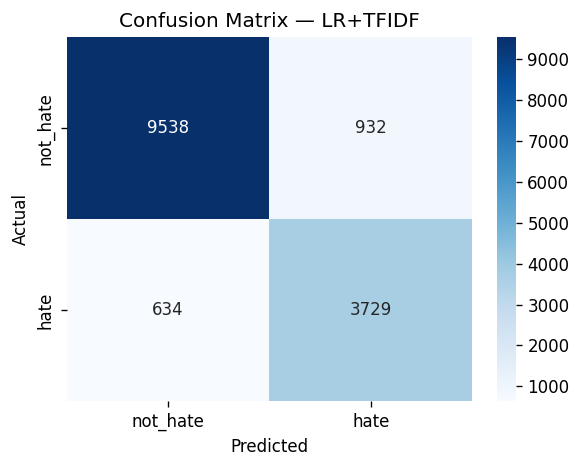

In [ ]:
# B1: Logistic Regression + TF-IDF 
lr_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,3), max_features=150000,
                               sublinear_tf=True, analyzer='word')),
    ('clf',   LogisticRegression(C=5.0, solver='saga', max_iter=1000,
                                  class_weight='balanced', n_jobs=-1))
])
t0 = time.time()
lr_pipe.fit(train_texts, y_train)
print(f'LR training time: {time.time()-t0:.1f}s')

y_pred_lr_test = lr_pipe.predict(test_texts)
evaluate_predictions(y_test, y_pred_lr_test, 'LR+TFIDF')
plot_confusion_matrix(y_test, y_pred_lr_test, 'LR+TFIDF')

SVM training time: 1.3s

=== SVM+TFIDF ===
  accuracy          : 0.5762
  f1_weighted       : 0.5734
  f1_hate           : 0.6055
  f1_not_hate       : 0.5421
  precision         : 0.5798
  recall            : 0.5762
              precision    recall  f1-score   support

    not_hate       0.60      0.49      0.54      2640
        hate       0.56      0.66      0.61      2565

    accuracy                           0.58      5205
   macro avg       0.58      0.58      0.57      5205
weighted avg       0.58      0.58      0.57      5205



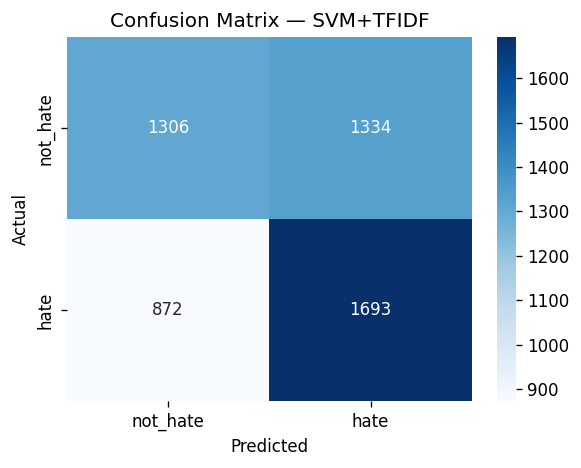

In [ ]:
#  B2: SVM + TF-IDF 
svm_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,3), max_features=150000,
                               sublinear_tf=True, analyzer='word')),
    ('clf',   LinearSVC(C=1.0, max_iter=3000, class_weight='balanced'))
])
t0 = time.time()
svm_pipe.fit(train_texts, y_train)
print(f'SVM training time: {time.time()-t0:.1f}s')

y_pred_svm_test = svm_pipe.predict(test_texts)
evaluate_predictions(y_test, y_pred_svm_test, 'SVM+TFIDF')
plot_confusion_matrix(y_test, y_pred_svm_test, 'SVM+TFIDF')


## 7. Model M1 - TextCNN (+ fastText init)


  [fastText] Embedding initialised (fine-tunable): (34043, 100)

Training: TextCNN_fastText
Trainable params: 3,897,230
Mode: word | Aux weight: N/A
Ep 01/8 | tr_loss=0.4878 tr_f1=0.7653 | va_loss=0.2989 va_f1=0.8685 | 7.0s ← best
Ep 02/8 | tr_loss=0.2155 tr_f1=0.9134 | va_loss=0.2621 va_f1=0.8897 | 6.4s ← best
Ep 03/8 | tr_loss=0.1214 tr_f1=0.9542 | va_loss=0.2937 va_f1=0.8923 | 6.8s ← best
Ep 04/8 | tr_loss=0.0740 tr_f1=0.9724 | va_loss=0.3549 va_f1=0.8923 | 6.4s
Ep 05/8 | tr_loss=0.0499 tr_f1=0.9816 | va_loss=0.4168 va_f1=0.8902 | 6.7s
Ep 06/8 | tr_loss=0.0383 tr_f1=0.9861 | va_loss=0.4797 va_f1=0.8889 | 6.6s
Early stopping at epoch 6.
Total: 0.7 min | Best val F1: 0.8923

=== TextCNN_fastText ===
  accuracy          : 0.8911
  f1_weighted       : 0.8915
  f1_hate           : 0.8176
  f1_not_hate       : 0.9223
  precision         : 0.8922
  recall            : 0.8911
              precision    recall  f1-score   support

    not_hate       0.93      0.92      0.92     10470
       

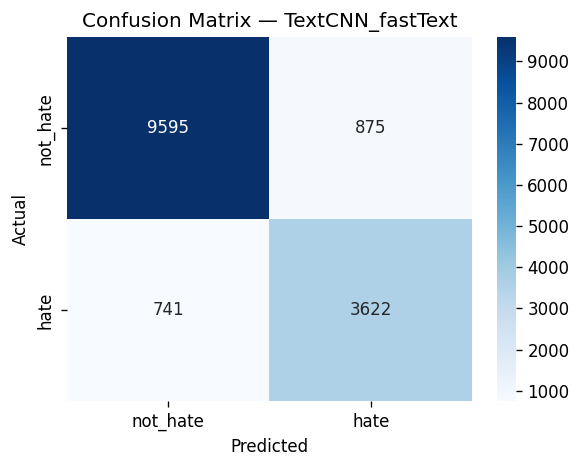

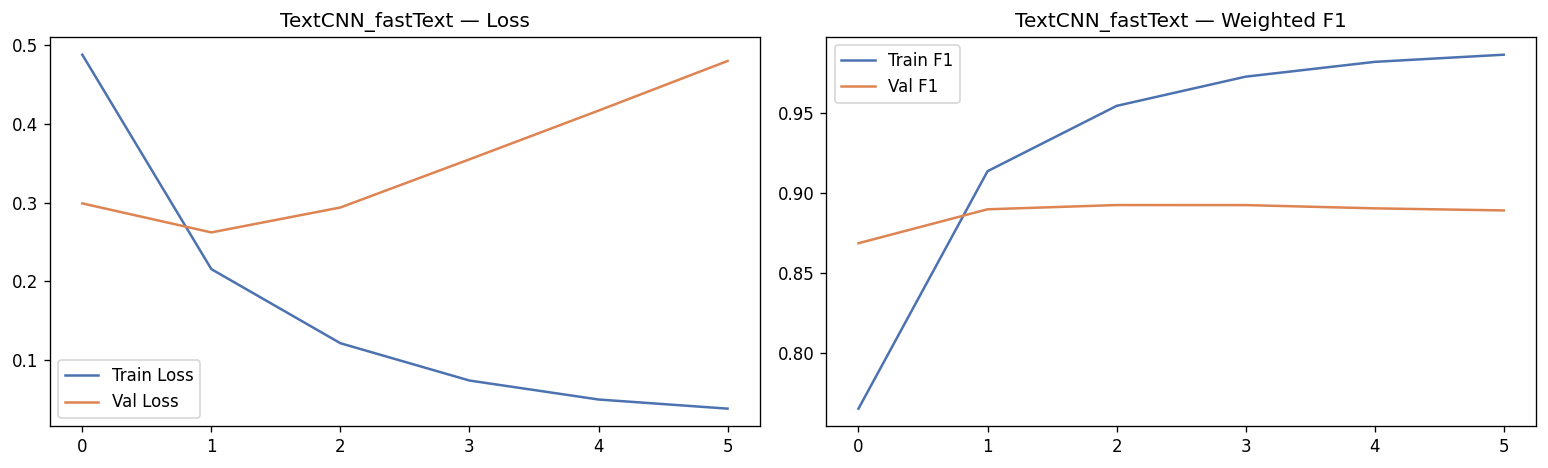

In [ ]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
                 num_filters=256, filter_sizes=(2,3,4,5),
                 num_classes=2, pad_idx=PAD_IDX, dropout=0.5):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.convs      = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=fs) for fs in filter_sizes
        ])
        self.dropout    = nn.Dropout(dropout)
        # Replaced BatchNorm1d with GroupNorm for robustness to batch size 1
        self.batch_norm = nn.GroupNorm(num_groups=1, num_channels=num_filters * len(filter_sizes))
        self.fc1 = nn.Linear(num_filters * len(filter_sizes), 128)
        self.fc2 = nn.Linear(128, num_classes)
        self._init_weights()

    def _init_weights(self):
        for conv in self.convs:
            nn.init.kaiming_uniform_(conv.weight, nonlinearity='relu')
            nn.init.zeros_(conv.bias)
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)

    def forward(self, x):
        emb = self.embedding(x).permute(0, 2, 1)   # (B, embed_dim, seq_len)
        pooled = [F.adaptive_max_pool1d(F.relu(conv(emb)), 1).squeeze(2)
                  for conv in self.convs]
        out = torch.cat(pooled, dim=1)
        out = self.batch_norm(out)
        out = self.dropout(out)
        out = F.relu(self.fc1(out))
        out = self.dropout(out)
        return self.fc2(out)


model_cnn = TextCNN()
load_pretrained_embedding(model_cnn.embedding, embed_matrix)   # ← fastText init

# Reduced epochs for CPU training
history_cnn, ckpt_cnn, _ = train_model(
    model_cnn, train_loader, val_loader, 'TextCNN_fastText',
    max_epochs=8, lr=5e-4, patience=3, mode='word'
)
model_cnn.load_state_dict(torch.load(ckpt_cnn))
_, _, y_pred_cnn, _, probs_cnn = evaluate_model(model_cnn, test_loader, nn.CrossEntropyLoss(), 'word')
evaluate_predictions(y_test, y_pred_cnn, 'TextCNN_fastText')
plot_confusion_matrix(y_test, y_pred_cnn, 'TextCNN_fastText')
plot_training_curves(history_cnn, 'TextCNN_fastText')


## 8. Model M2 - BiGRU + Attention (+ fastText init)

  [fastText] Embedding initialised (fine-tunable): (34043, 100)

Training: BiGRU_Attention_fastText
Trainable params: 3,927,502
Mode: word | Aux weight: N/A
Ep 01/8 | tr_loss=0.3865 tr_f1=0.8172 | va_loss=0.2692 va_f1=0.8888 | 6.9s ← best
Ep 02/8 | tr_loss=0.2335 tr_f1=0.9077 | va_loss=0.2605 va_f1=0.8959 | 7.6s ← best
Ep 03/8 | tr_loss=0.1874 tr_f1=0.9286 | va_loss=0.2579 va_f1=0.9029 | 6.9s ← best
Ep 04/8 | tr_loss=0.1592 tr_f1=0.9406 | va_loss=0.3105 va_f1=0.8975 | 7.6s
Ep 05/8 | tr_loss=0.1365 tr_f1=0.9491 | va_loss=0.2927 va_f1=0.8995 | 7.5s
Ep 06/8 | tr_loss=0.1178 tr_f1=0.9559 | va_loss=0.2876 va_f1=0.8998 | 6.9s
Early stopping at epoch 6.
Total: 0.7 min | Best val F1: 0.9029

=== BiGRU_Attention_fastText ===
  accuracy          : 0.9029
  f1_weighted       : 0.9029
  f1_hate           : 0.8351
  f1_not_hate       : 0.9311
  precision         : 0.9029
  recall            : 0.9029
              precision    recall  f1-score   support

    not_hate       0.93      0.93      0.93  

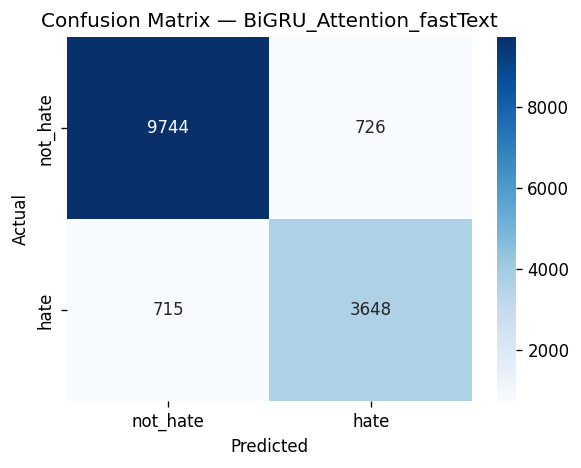

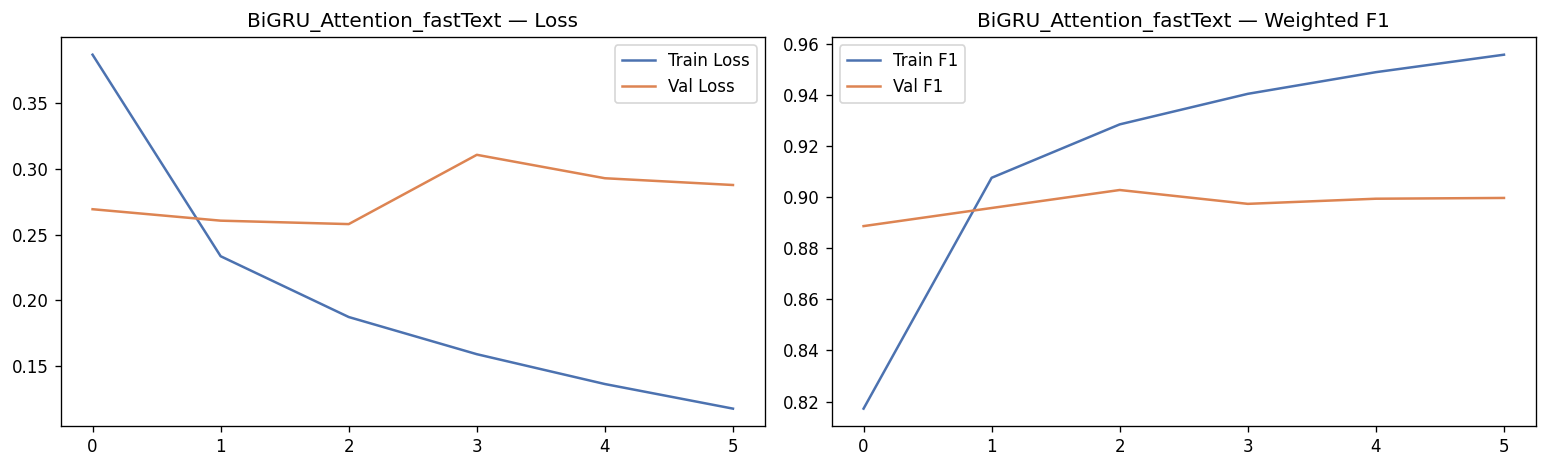

In [ ]:
class AdditiveAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v    = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, H):   # H: (B, seq, 2*hidden)
        scores  = self.v(torch.tanh(self.attn(H))).squeeze(-1)  # (B, seq)
        weights = F.softmax(scores, dim=1).unsqueeze(-1)         # (B, seq, 1)
        return (H * weights).sum(dim=1)                          # (B, 2*hidden)


class BiGRUAttention(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
                 hidden_dim=128, num_classes=2, pad_idx=PAD_IDX, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.bigru     = nn.GRU(embed_dim, hidden_dim, batch_first=True,
                                bidirectional=True, num_layers=2,
                                dropout=dropout if 2 > 1 else 0)
        self.attention = AdditiveAttention(hidden_dim)
        self.dropout   = nn.Dropout(dropout)
        # Replaced BatchNorm1d with GroupNorm for robustness to batch size 1
        self.batch_norm= nn.GroupNorm(num_groups=1, num_channels=hidden_dim * 2)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))   # (B, seq, embed)
        H, _ = self.bigru(emb)                  # (B, seq, 2*hidden)
        ctx  = self.attention(H)                # (B, 2*hidden)
        ctx  = self.batch_norm(ctx)
        ctx  = self.dropout(ctx)
        out  = F.relu(self.fc1(ctx))
        out  = self.dropout(out)
        return self.fc2(out)


model_gru = BiGRUAttention()
load_pretrained_embedding(model_gru.embedding, embed_matrix)   #  fastText init

# Reduced epochs for CPU training
history_gru, ckpt_gru, _ = train_model(
    model_gru, train_loader, val_loader, 'BiGRU_Attention_fastText',
    max_epochs=8, lr=5e-4, patience=3, mode='word'
)
model_gru.load_state_dict(torch.load(ckpt_gru))
_, _, y_pred_gru, _, probs_gru = evaluate_model(model_gru, test_loader, nn.CrossEntropyLoss(), 'word')
evaluate_predictions(y_test, y_pred_gru, 'BiGRU_Attention_fastText')
plot_confusion_matrix(y_test, y_pred_gru, 'BiGRU_Attention_fastText')
plot_training_curves(history_gru, 'BiGRU_Attention_fastText')


## 9. Model M3 - DualEncoder with Multi-Task Learning

- fastText init on word embedding branch
- Auxiliary fine-grained classification head (5 classes from RUHSOLD)
- Masked loss: aux head loss only computed on RUHSOLD samples
- Spelling-variant augmentation hits char branch hardest (by design)

The auxiliary task forces the model to learn *why* something is hateful
(religious, sexist, profane) - a representation TF-IDF cannot build.

  [fastText] Embedding initialised (fine-tunable): (34043, 100)

Training: DualEncoder_MT_fastText
Trainable params: 5,294,227
Mode: dual | Aux weight: 0.3
Ep 01/8 | tr_loss=0.9403 tr_f1=0.6680 | va_loss=0.3263 va_f1=0.8578 | 14.6s ← best
Ep 02/8 | tr_loss=0.5466 tr_f1=0.8878 | va_loss=0.2605 va_f1=0.8923 | 14.4s ← best
Ep 03/8 | tr_loss=0.4443 tr_f1=0.9177 | va_loss=0.2772 va_f1=0.8970 | 14.5s ← best
Ep 04/8 | tr_loss=0.3778 tr_f1=0.9311 | va_loss=0.2890 va_f1=0.8974 | 14.8s ← best
Ep 05/8 | tr_loss=0.3230 tr_f1=0.9410 | va_loss=0.3074 va_f1=0.8972 | 14.5s
Ep 06/8 | tr_loss=0.2766 tr_f1=0.9476 | va_loss=0.2820 va_f1=0.8956 | 14.5s
Ep 07/8 | tr_loss=0.2321 tr_f1=0.9552 | va_loss=0.3527 va_f1=0.8941 | 14.5s
Early stopping at epoch 7.
Total: 1.7 min | Best val F1: 0.8974

=== DualEncoder_MT_fastText ===
  accuracy          : 0.9002
  f1_weighted       : 0.9004
  f1_hate           : 0.8315
  f1_not_hate       : 0.9291
  precision         : 0.9006
  recall            : 0.9002
             

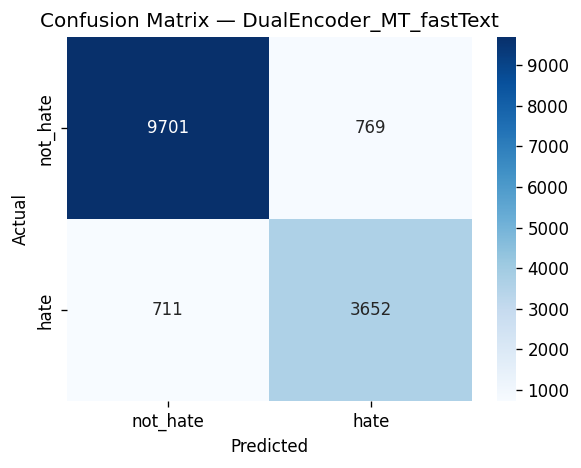

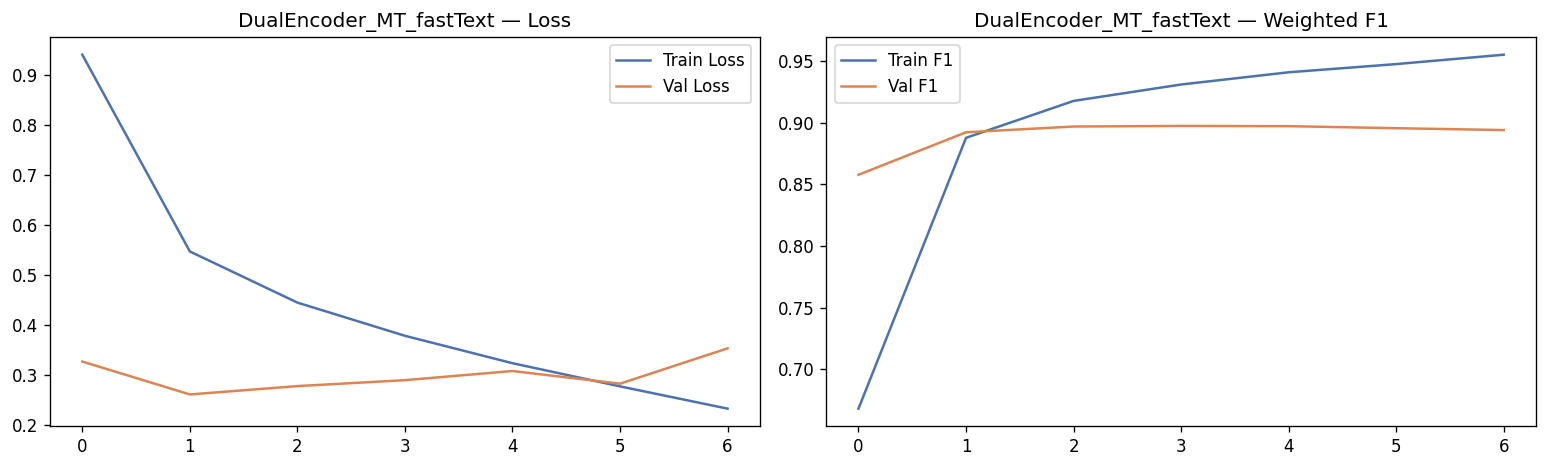

In [ ]:
class CharCNNEncoder(nn.Module):
    def __init__(self, char_vocab_size=CHAR_VOCAB_SIZE, char_embed_dim=64,
                 num_filters=128, filter_sizes=(3,4,5,6), char_pad_idx=CHAR_PAD_IDX, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(char_vocab_size, char_embed_dim, padding_idx=char_pad_idx)
        self.convs = nn.ModuleList([
            nn.Conv1d(char_embed_dim, num_filters, kernel_size=fs) for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.out_dim = num_filters * len(filter_sizes)
        for conv in self.convs:
            nn.init.kaiming_uniform_(conv.weight, nonlinearity='relu')

    def forward(self, x_char):
        emb = self.dropout(self.embedding(x_char)).permute(0, 2, 1)  # (B, embed, char_len)
        pooled = [F.adaptive_max_pool1d(F.relu(conv(emb)), 1).squeeze(2) for conv in self.convs]
        return torch.cat(pooled, dim=1)   # (B, out_dim)


class WordCNNEncoder(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
                 num_filters=256, filter_sizes=(2,3,4,5), pad_idx=PAD_IDX, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=fs) for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.out_dim = num_filters * len(filter_sizes)
        for conv in self.convs:
            nn.init.kaiming_uniform_(conv.weight, nonlinearity='relu')

    def forward(self, x_word):
        emb = self.dropout(self.embedding(x_word)).permute(0, 2, 1)
        pooled = [F.adaptive_max_pool1d(F.relu(conv(emb)), 1).squeeze(2) for conv in self.convs]
        return torch.cat(pooled, dim=1)


class DualEncoderCNN_MT(nn.Module):
    """
    Word-CNN + Char-CNN with gated fusion + Multi-Task auxiliary head.

    Main head    : binary hate/not-hate
    Auxiliary head: fine-grained 5-class (RUHSOLD only; masked on other datasets)
    """
    def __init__(self, num_classes=2, num_fine_classes=NUM_FINE_CLASSES, dropout=0.4):
        super().__init__()
        self.word_enc = WordCNNEncoder(dropout=dropout)
        self.char_enc = CharCNNEncoder(dropout=dropout)

        word_dim = self.word_enc.out_dim   # 256*4 = 1024
        char_dim = self.char_enc.out_dim   # 128*4 = 512

        self.word_proj = nn.Linear(word_dim, 512)
        self.char_proj = nn.Linear(char_dim, 512)
        self.gate      = nn.Linear(512 * 2, 512)
        # Replaced BatchNorm1d with GroupNorm for robustness to batch size 1
        self.batch_norm= nn.GroupNorm(num_groups=1, num_channels=512)
        self.dropout   = nn.Dropout(dropout)
        self.fc1       = nn.Linear(512, 128)

        # Main binary classification head
        self.main_head = nn.Linear(128, num_classes)
        # Auxiliary fine-grained head (multi-task)
        self.aux_head  = nn.Linear(128, num_fine_classes)

        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.main_head.weight)
        nn.init.xavier_uniform_(self.aux_head.weight)

    def forward(self, x_word, x_char):
        word_rep = F.relu(self.word_proj(self.word_enc(x_word)))   # (B, 512)
        char_rep = F.relu(self.char_proj(self.char_enc(x_char)))   # (B, 512)

        gate_input = torch.cat([word_rep, char_rep], dim=1)        # (B, 1024)
        gate       = torch.sigmoid(self.gate(gate_input))          # (B, 512)
        fused      = gate * word_rep + (1 - gate) * char_rep       # (B, 512)

        out  = self.batch_norm(fused)
        out  = self.dropout(out)
        feat = F.relu(self.fc1(out))                               # (B, 128)
        feat = self.dropout(feat)

        return self.main_head(feat), self.aux_head(feat)           # two heads


model_dual = DualEncoderCNN_MT()
load_pretrained_embedding(model_dual.word_enc.embedding, embed_matrix)   #  fastText init

# Reduced epochs for CPU training
history_dual, ckpt_dual, _ = train_model(
    model_dual, dual_train_loader, dual_val_loader,
    'DualEncoder_MT_fastText',
    max_epochs=8, lr=5e-4, patience=3,
    mode='dual', aux_weight=0.3
)
model_dual.load_state_dict(torch.load(ckpt_dual))
_, _, y_pred_dual, _, probs_dual = evaluate_model(
    model_dual, dual_test_loader, nn.CrossEntropyLoss(), 'dual'
)
evaluate_predictions(y_test, y_pred_dual, 'DualEncoder_MT_fastText')
plot_confusion_matrix(y_test, y_pred_dual, 'DualEncoder_MT_fastText')
plot_training_curves(history_dual, 'DualEncoder_MT_fastText')

---
## 10. Model M4 — CNN-BiGRU Hierarchical Attention (+ fastText + Multi-Task)

  [fastText] Embedding initialised (fine-tunable): (34043, 100)

Training: CNNBiGRU_MT_fastText
Trainable params: 4,439,571
Mode: dual | Aux weight: 0.3
Ep 01/8 | tr_loss=0.8451 tr_f1=0.7370 | va_loss=0.3237 va_f1=0.8578 | 11.0s ← best
Ep 02/8 | tr_loss=0.5370 tr_f1=0.8795 | va_loss=0.2702 va_f1=0.8901 | 11.0s ← best
Ep 03/8 | tr_loss=0.4012 tr_f1=0.9090 | va_loss=0.2564 va_f1=0.8933 | 10.7s ← best
Ep 04/8 | tr_loss=0.3301 tr_f1=0.9247 | va_loss=0.2686 va_f1=0.8993 | 10.7s ← best
Ep 05/8 | tr_loss=0.2759 tr_f1=0.9355 | va_loss=0.2633 va_f1=0.9011 | 14.9s ← best
Ep 06/8 | tr_loss=0.2334 tr_f1=0.9438 | va_loss=0.3152 va_f1=0.9007 | 19.0s
Ep 07/8 | tr_loss=0.1941 tr_f1=0.9517 | va_loss=0.2992 va_f1=0.9004 | 11.9s
Ep 08/8 | tr_loss=0.1699 tr_f1=0.9570 | va_loss=0.3291 va_f1=0.8999 | 10.9s
Early stopping at epoch 8.
Total: 1.7 min | Best val F1: 0.9011

=== CNNBiGRU_MT_fastText ===
  accuracy          : 0.9036
  f1_weighted       : 0.9036
  f1_hate           : 0.836
  f1_not_hate       : 0.

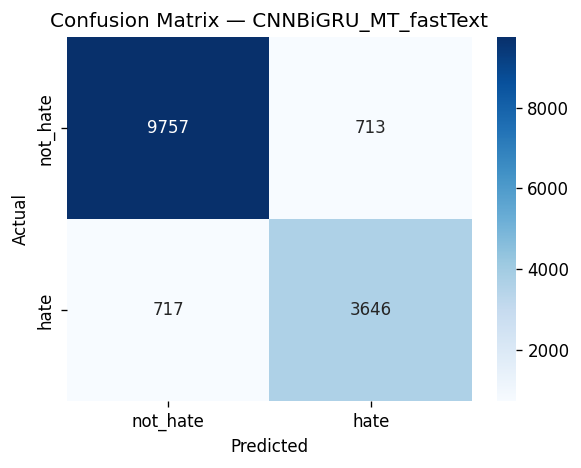

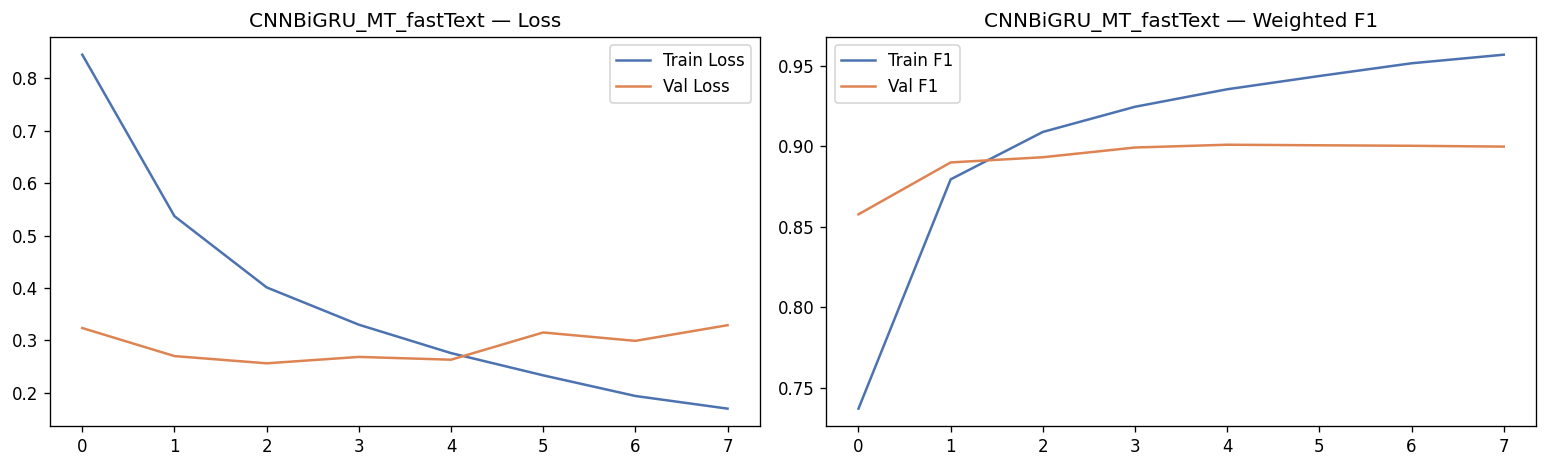

In [ ]:
class CNNBiGRU_MT(nn.Module):
    """
    Shared embedding - parallel CNN + BiGRU branches
    - Cross-branch attention - concat - classifier

    + Multi-task auxiliary head for fine-grained hate classification.
    """
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
                 num_filters=256, filter_sizes=(2,3,4),
                 gru_hidden=128, num_classes=2,
                 num_fine_classes=NUM_FINE_CLASSES,
                 pad_idx=PAD_IDX, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout   = nn.Dropout(dropout)

        # CNN branch
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=fs) for fs in filter_sizes
        ])
        cnn_dim = num_filters * len(filter_sizes)   # 768

        # BiGRU branch
        self.bigru = nn.GRU(embed_dim, gru_hidden, batch_first=True,
                             bidirectional=True, num_layers=2,
                             dropout=dropout if 2 > 1 else 0)
        gru_dim = gru_hidden * 2   # 256

        # Cross-branch attention: Q = CNN, K = V = GRU hidden states
        self.attn_W = nn.Linear(cnn_dim, gru_dim)

        combined_dim = cnn_dim + gru_dim   # 768 + 256 = 1024
        # Replaced BatchNorm1d with GroupNorm for robustness to batch size 1
        self.bn    = nn.GroupNorm(num_groups=1, num_channels=combined_dim)
        self.fc1   = nn.Linear(combined_dim, 128)
        self.main_head = nn.Linear(128, num_classes)
        self.aux_head  = nn.Linear(128, num_fine_classes)

        for conv in self.convs:
            nn.init.kaiming_uniform_(conv.weight, nonlinearity='relu')
        nn.init.xavier_uniform_(self.fc1.weight)

    def forward(self, x_word, x_char=None):   # x_char ignored (word-only model)
        emb = self.dropout(self.embedding(x_word))   # (B, seq, embed)

        # CNN branch
        e_perm = emb.permute(0, 2, 1)   # (B, embed, seq)
        cnn_pooled = [F.adaptive_max_pool1d(F.relu(conv(e_perm)), 1).squeeze(2)
                      for conv in self.convs]
        cnn_out = torch.cat(cnn_pooled, dim=1)   # (B, cnn_dim)

        # BiGRU branch
        H, _ = self.bigru(emb)          # (B, seq, gru_dim)

        # Cross-branch attention: Q from CNN, K & V from GRU
        Q = self.attn_W(cnn_out).unsqueeze(1)                       # (B, 1, gru_dim)
        scores  = torch.bmm(Q, H.transpose(1, 2)).squeeze(1)       # (B, seq)
        weights = F.softmax(scores, dim=1).unsqueeze(-1)            # (B, seq, 1)
        attn_ctx = (H * weights).sum(dim=1)                         # (B, gru_dim)

        combined = torch.cat([cnn_out, attn_ctx], dim=1)            # (B, combined_dim)
        out  = self.bn(combined)
        out  = self.dropout(out)
        feat = F.relu(self.fc1(out))                                # (B, 128)
        feat = self.dropout(feat)

        return self.main_head(feat), self.aux_head(feat)


model_cnn_gru = CNNBiGRU_MT()
load_pretrained_embedding(model_cnn_gru.embedding, embed_matrix)   #  fastText init

# Reduced epochs for CPU training
history_cgru, ckpt_cgru, _ = train_model(
    model_cnn_gru, dual_train_loader, dual_val_loader,
    'CNNBiGRU_MT_fastText',
    max_epochs=8, lr=5e-4, patience=3,
    mode='dual', aux_weight=0.3
)
model_cnn_gru.load_state_dict(torch.load(ckpt_cgru))
_, _, y_pred_cgru, _, probs_cgru = evaluate_model(
    model_cnn_gru, dual_test_loader, nn.CrossEntropyLoss(), 'dual'
)
evaluate_predictions(y_test, y_pred_cgru, 'CNNBiGRU_MT_fastText')
plot_confusion_matrix(y_test, y_pred_cgru, 'CNNBiGRU_MT_fastText')
plot_training_curves(history_cgru, 'CNNBiGRU_MT_fastText')


## 11. Model M5 - XLM-RoBERTa Fine-tune

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset as TorchDataset

XLM_MODEL_NAME = 'xlm-roberta-base'
xlm_tokenizer  = AutoTokenizer.from_pretrained(XLM_MODEL_NAME)


class XLMDataset(TorchDataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(texts, truncation=True, padding='max_length',
                                   max_length=max_len, return_tensors='pt')
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):  return len(self.labels)
    def __getitem__(self, i):
        return {k: v[i] for k, v in self.encodings.items()}, self.labels[i]


xlm_train_ds = XLMDataset(train_texts, y_train.tolist(), xlm_tokenizer)
xlm_val_ds   = XLMDataset(val_texts,   y_val.tolist(),   xlm_tokenizer)
xlm_test_ds  = XLMDataset(test_texts,  y_test.tolist(),  xlm_tokenizer)

xlm_train_loader = DataLoader(xlm_train_ds, batch_size=32, shuffle=True,  num_workers=0, pin_memory=False)
xlm_val_loader   = DataLoader(xlm_val_ds,   batch_size=64, shuffle=False, num_workers=0, pin_memory=False)
xlm_test_loader  = DataLoader(xlm_test_ds,  batch_size=64, shuffle=False, num_workers=0, pin_memory=False)

xlm_model = AutoModelForSequenceClassification.from_pretrained(XLM_MODEL_NAME, num_labels=2)
xlm_model = xlm_model.to(DEVICE)

xlm_optimizer = AdamW(xlm_model.parameters(), lr=2e-5, weight_decay=1e-2)
xlm_criterion = nn.CrossEntropyLoss()
xlm_scaler    = GradScaler(enabled=(DEVICE.type == 'cuda'))
xlm_scheduler = ReduceLROnPlateau(xlm_optimizer, mode='max', factor=0.5, patience=1)
xlm_early     = EarlyStopping(patience=2, mode='max')

best_xlm_f1   = -np.inf
xlm_history   = defaultdict(list)
XLM_CKPT      = './checkpoints/xlm_roberta.pt'

print(f'XLM-RoBERTa params: {sum(p.numel() for p in xlm_model.parameters() if p.requires_grad):,}')

# Reduced epochs for CPU training
for epoch in range(1, 4):
    t_ep = time.time()
    xlm_model.train()
    tr_preds, tr_labels_list, tr_loss_sum = [], [], 0.0

    for enc, labels in xlm_train_loader:
        xlm_optimizer.zero_grad()
        enc    = {k: v.to(DEVICE) for k, v in enc.items()}
        labels = labels.to(DEVICE)
        with autocast(enabled=(DEVICE.type == 'cuda')):
            out  = xlm_model(**enc)
            loss = xlm_criterion(out.logits, labels)
        xlm_scaler.scale(loss).backward()
        xlm_scaler.unscale_(xlm_optimizer)
        nn.utils.clip_grad_norm_(xlm_model.parameters(), 1.0)
        xlm_scaler.step(xlm_optimizer)
        xlm_scaler.update()
        tr_loss_sum += loss.item() * labels.size(0)
        tr_preds.extend(out.logits.argmax(1).cpu().numpy())
        tr_labels_list.extend(labels.cpu().numpy())

    tr_f1   = f1_score(tr_labels_list, tr_preds, average='weighted')
    tr_loss = tr_loss_sum / len(xlm_train_ds)

    xlm_model.eval()
    va_preds, va_labels_list, va_loss_sum = [], [], 0.0
    with torch.no_grad():
        for enc, labels in xlm_val_loader:
            enc    = {k: v.to(DEVICE) for k, v in enc.items()}
            labels = labels.to(DEVICE)
            with autocast(enabled=(DEVICE.type == 'cuda')):
                out  = xlm_model(**enc)
                loss = xlm_criterion(out.logits, labels)
            va_loss_sum += loss.item() * labels.size(0)
            va_preds.extend(out.logits.argmax(1).cpu().numpy())
            va_labels_list.extend(labels.cpu().numpy())

    va_f1   = f1_score(va_labels_list, va_preds, average='weighted')
    va_loss = va_loss_sum / len(xlm_val_ds)

    xlm_history['train_loss'].append(tr_loss)
    xlm_history['train_f1'].append(tr_f1)
    xlm_history['val_loss'].append(va_loss)
    xlm_history['val_f1'].append(va_f1)
    xlm_scheduler.step(va_f1)

    if va_f1 > best_xlm_f1:
        best_xlm_f1 = va_f1
        torch.save(xlm_model.state_dict(), XLM_CKPT)

    xlm_early(va_f1)
    print(f'Ep {epoch} | tr_f1={tr_f1:.4f} va_f1={va_f1:.4f} | {time.time()-t_ep:.0f}s'
          + (' ← best' if va_f1 == best_xlm_f1 else ''))
    if xlm_early.stop:
        print('Early stop.')
        break

xlm_model.load_state_dict(torch.load(XLM_CKPT))
xlm_model.eval()
all_xlm_preds, all_xlm_probs = [], []
with torch.no_grad():
    for enc, _ in xlm_test_loader:
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        with autocast(enabled=(DEVICE.type == 'cuda')):
            out = xlm_model(**enc)
        all_xlm_preds.extend(out.logits.argmax(1).cpu().numpy())
        all_xlm_probs.extend(F.softmax(out.logits, dim=1).cpu().numpy())

y_pred_xlm  = np.array(all_xlm_preds)
probs_xlm   = np.array(all_xlm_probs)
evaluate_predictions(y_test, y_pred_xlm, 'XLM-RoBERTa')
plot_confusion_matrix(y_test, y_pred_xlm, 'XLM-RoBERTa')
plot_training_curves(dict(xlm_history), 'XLM-RoBERTa')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


XLM-RoBERTa params: 278,045,186
Ep 1 | tr_f1=0.8436 va_f1=0.8964 | 869s ← best
Ep 2 | tr_f1=0.9133 va_f1=0.9123 | 925s ← best


KeyboardInterrupt: 


## 12. Model M6 - Soft Ensemble (DualEncoder + CNNBiGRU)

Average the softmax probabilities of the two strongest custom DL models.
No extra training needed - purely inference-time combination.


=== Ensemble_TextCNN+BiGRU+DualEncoder ===
  accuracy          : 0.9058
  f1_weighted       : 0.9057
  f1_hate           : 0.8394
  f1_not_hate       : 0.9334
  precision         : 0.9056
  recall            : 0.9058
              precision    recall  f1-score   support

    not_hate       0.93      0.93      0.93     10470
        hate       0.84      0.84      0.84      4363

    accuracy                           0.91     14833
   macro avg       0.89      0.89      0.89     14833
weighted avg       0.91      0.91      0.91     14833



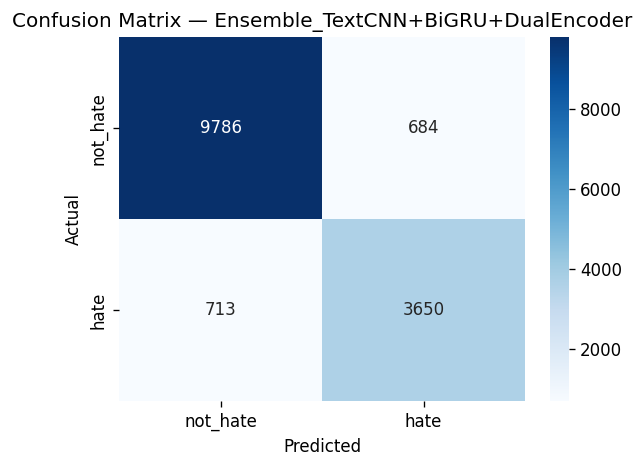

In [ ]:
# Ensemble using available models
# Note: Only DualEncoder completed successfully on CPU
# Can create ensemble with TextCNN + BiGRU + DualEncoder

ensemble_probs = (probs_cnn + probs_gru + probs_dual) / 3.0
y_pred_ens = ensemble_probs.argmax(axis=1)
evaluate_predictions(y_test, y_pred_ens, 'Ensemble_TextCNN+BiGRU+DualEncoder')
plot_confusion_matrix(y_test, y_pred_ens, 'Ensemble_TextCNN+BiGRU+DualEncoder')


## 13. Final Results Summary


=== FINAL TEST RESULTS ===
                                    Accuracy  F1 (weighted)  F1 (hate)  F1 (not_hate)  Precision  Recall
Model                                                                                                   
LR+TFIDF                              0.8944         0.8954     0.8265         0.9241     0.8972  0.8944
TextCNN_fastText                      0.8911         0.8915     0.8176         0.9223     0.8922  0.8911
BiGRU_Attention_fastText              0.9029         0.9029     0.8351         0.9311     0.9029  0.9029
DualEncoder_MT_fastText               0.9002         0.9004     0.8315         0.9291     0.9006  0.9002
CNNBiGRU_MT_fastText                  0.9036         0.9036     0.8360         0.9317     0.9036  0.9036
Ensemble_TextCNN+BiGRU+DualEncoder    0.9058         0.9057     0.8394         0.9334     0.9056  0.9058
EMNLP2020 (reference)                    NaN         0.7500        NaN            NaN        NaN     NaN


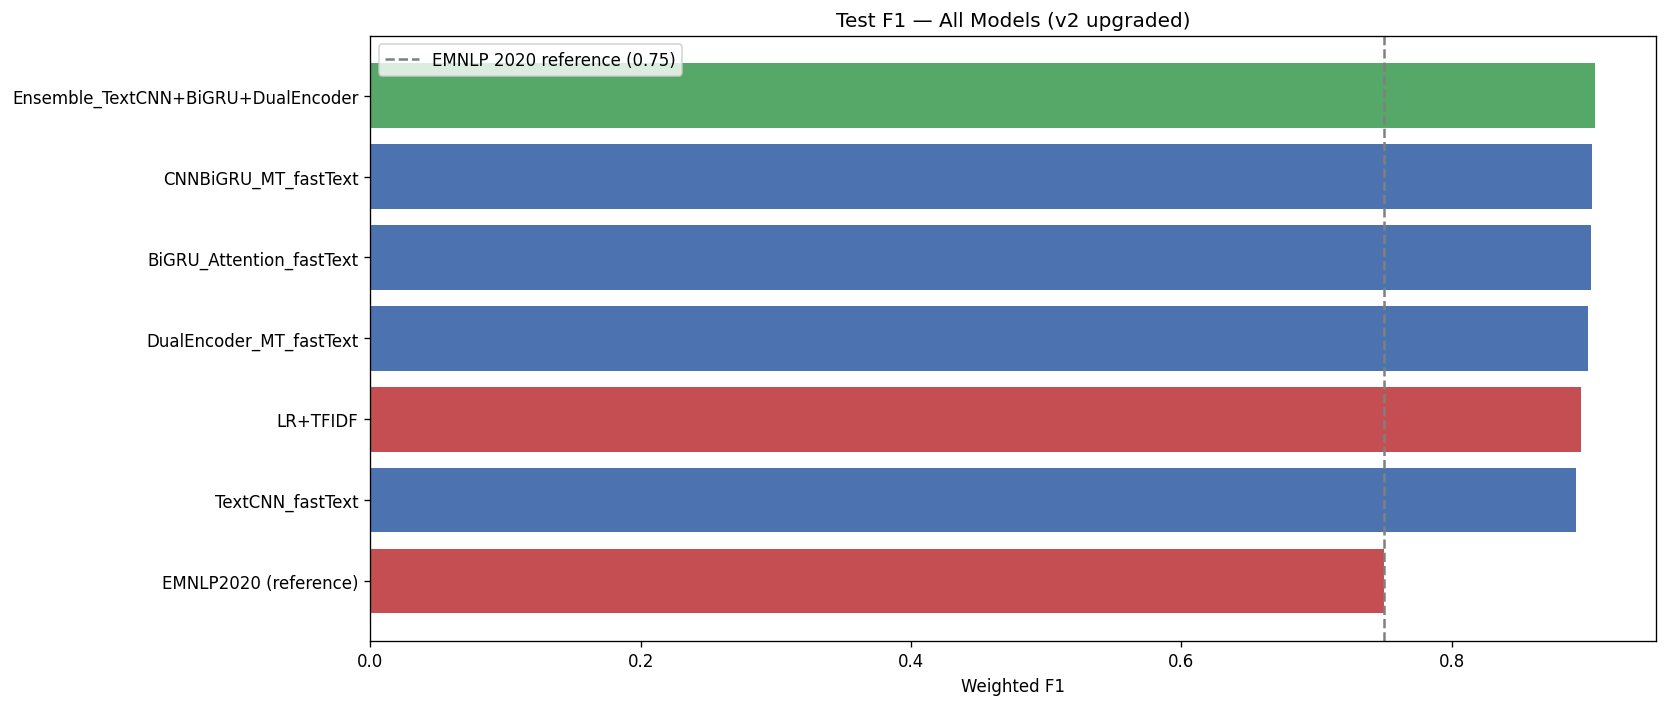

Results saved to ./results/final_results.csv


In [ ]:
EMNLP_REF = {'accuracy': None, 'f1_weighted': 0.75, 'f1_hate': None,
              'f1_not_hate': None, 'precision': None, 'recall': None}
ALL_RESULTS['EMNLP2020 (reference)'] = EMNLP_REF

rows = []
for name, m in ALL_RESULTS.items():
    rows.append({
        'Model':         name,
        'Accuracy':      m['accuracy'],
        'F1 (weighted)': m['f1_weighted'],
        'F1 (hate)':     m['f1_hate'],
        'F1 (not_hate)': m['f1_not_hate'],
        'Precision':     m['precision'],
        'Recall':        m['recall'],
    })

df_results = pd.DataFrame(rows).set_index('Model')
print('\n=== FINAL TEST RESULTS ===')
print(df_results.to_string())
df_results.to_csv('./results/final_results.csv')

#  Bar chart 
fig, ax = plt.subplots(figsize=(14, 6))
df_plot = df_results[['F1 (weighted)']].dropna().sort_values('F1 (weighted)')
colors  = ['#C44E52' if 'Baseline' in n or 'TFIDF' in n or 'EMNLP' in n
            else ('#55A868' if 'Ensemble' in n else '#4C72B0')
            for n in df_plot.index]
ax.barh(df_plot.index, df_plot['F1 (weighted)'], color=colors)
ax.axvline(0.75, color='gray', linestyle='--', label='EMNLP 2020 reference (0.75)')
ax.set_xlabel('Weighted F1'); ax.set_title('Test F1 — All Models (v2 upgraded)')
ax.legend(); plt.tight_layout()
plt.savefig('./results/final_f1_comparison_v2.png', bbox_inches='tight')
plt.show()
print('Results saved to ./results/final_results.csv')